# Fitting Landau Distribution from Simulations to Experimental Data Curves

Author: Dhruv Sharma

In [226]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mplhep
from pathlib import Path

### Get Simulation Data

In [227]:
sim_file = uproot.open("/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix/outputs/sparse_sim_run_1.root")
events = sim_file["Events"].arrays(library="np")
print(f"Total events (Electrons): {len(events['eventID'])}")
print(f"Mean total Edep: {np.mean(events['totalEdep_keV']):.2f} keV")
print(f"Mean primary Edep: {np.mean(events['primaryEdep_keV']):.2f} keV")

Total events (Electrons): 25000
Mean total Edep: 176.14 keV
Mean primary Edep: 117.30 keV


### Get Experimental Data

In [228]:
def get_hist_mean(hist):
    counts, edges = hist[0], hist[1]
    bin_centers = (edges[:-1] + edges[1:]) / 2
    mean = np.average(bin_centers, weights=counts)
    return mean

def get_exp_data(run):
    exp_py = np.load("/sdf/home/d/dhruvshr/SULI2026/ePix_Analysis/catalog/Intensity_evts"+str(run)+".npy")
    bins_intn=np.arange(80,1000,5)
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(exp_py[:,i_mdl,:].flatten(), bins=bins_intn)
        all_counts.append(hist_intn)
    exp_counts = np.mean(np.array(all_counts), axis=0)
    return exp_counts

In [229]:
# Med Gain
exp_126 = get_exp_data(126)
exp_115 = get_exp_data(115)

# High Gain
exp_153 = get_exp_data(153)
exp_491 = get_exp_data(491)

## Landau Fitting of Simulation to Experimental Data for Med/High Gain Runs

In [230]:
len(exp_data)

200

In [231]:
from scipy.ndimage import gaussian_filter1d
import numpy as np

sim_file = uproot.open("/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix/outputs/sparse_sim_run_1.root")
events = sim_file["Events"].arrays(library="np")
sim_edeps = events['totalEdep_keV']

bins = np.linspace(0, 1000, 201)
bin_edges = np.linspace(80,995,184)
num_events = len(sim_edeps)

# graph the above sim data in comparison to an experimental run given as a parameter)
def make_graph(exp_data, double_p, triple_p, sigma_single, sigma_double, sigma_triple):    
    # Fractions (these are what you tune)
    double_percentage = double_p # 0.13
    triple_percentage = triple_p # 0.03
    sigma_single = sigma_single # 25  # detector resolution in keV
    sigma_double = sigma_double # 27
    sigma_triple = sigma_triple # 30
    
    # Event counts
    single_fraction = 1.0 - double_percentage - triple_percentage
    single_size = int(single_fraction * num_events)
    double_size = int(double_percentage * num_events)
    triple_size = int(triple_percentage * num_events)
    
    # Singles: only the fraction that are truly single events
    single_idxs = np.random.choice(num_events, size=single_size, replace=True)
    singles = sim_edeps[single_idxs]
    
    # Doubles: SUM of two independent single-electron energy deposits
    doubles = (sim_edeps[np.random.choice(num_events, size=double_size, replace=True)] +
               sim_edeps[np.random.choice(num_events, size=double_size, replace=True)])
    
    # Triples: SUM of three independent single-electron energy deposits
    triples = (sim_edeps[np.random.choice(num_events, size=triple_size, replace=True)] +
               sim_edeps[np.random.choice(num_events, size=triple_size, replace=True)] +
               sim_edeps[np.random.choice(num_events, size=triple_size, replace=True)])
    
    # Histogram (use np.histogram, not plt.hist with alpha=0)
    counts_single, _ = np.histogram(singles, bins)
    counts_double, _ = np.histogram(doubles, bins)
    counts_triple, _ = np.histogram(triples, bins)
    
    # Gaussian convolution (detector resolution)
    sigma_bins_single = (sigma_single) / (bins[1] - bins[0])
    sigma_bins_double = (sigma_double) / (bins[1] - bins[0])
    sigma_bins_triple = (sigma_triple) / (bins[1] - bins[0])
    
    conv_singles_old = gaussian_filter1d(counts_single.astype(float), sigma_bins_single, mode='constant', cval=0)
    conv_doubles = gaussian_filter1d(counts_double.astype(float), sigma_bins_double, mode='constant', cval=0)
    conv_triples = gaussian_filter1d(counts_triple.astype(float), sigma_bins_triple, mode='constant', cval=0)

    conv_singles = conv_singles_old
    #conv_singles = np.insert(conv_singles_old, 0, 0)[:-1] # thermal shifting by one bin (5 keV)
    
    conv_singles[:25]=0.0
    conv_doubles[:25]=0.0
    conv_triples[:25]=0.0
    
    combined = conv_singles + conv_doubles + conv_triples

    # CORRECT scaling: match total area
    total_sim_counts = np.sum(combined)
    total_exp_counts = np.sum(exp_data)
    
    # Rebin experimental data into the same bins as simulation
    bin_centers_exp = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    avg_counts_rebinned, _ = np.histogram(bin_centers_exp, bins=bins, weights=exp_data)
    
    # Now scaling is straightforward
    counts_scale = total_sim_counts / np.sum(avg_counts_rebinned)
    scaled_exp = avg_counts_rebinned * counts_scale

    return [conv_singles, conv_doubles, conv_triples, combined, scaled_exp]

The graphs fundamentally can't be fit well due to the ~25 keV horizontal translation between the simulation and experimental observations (discrepancy is yet to be resolved)

#### Plots

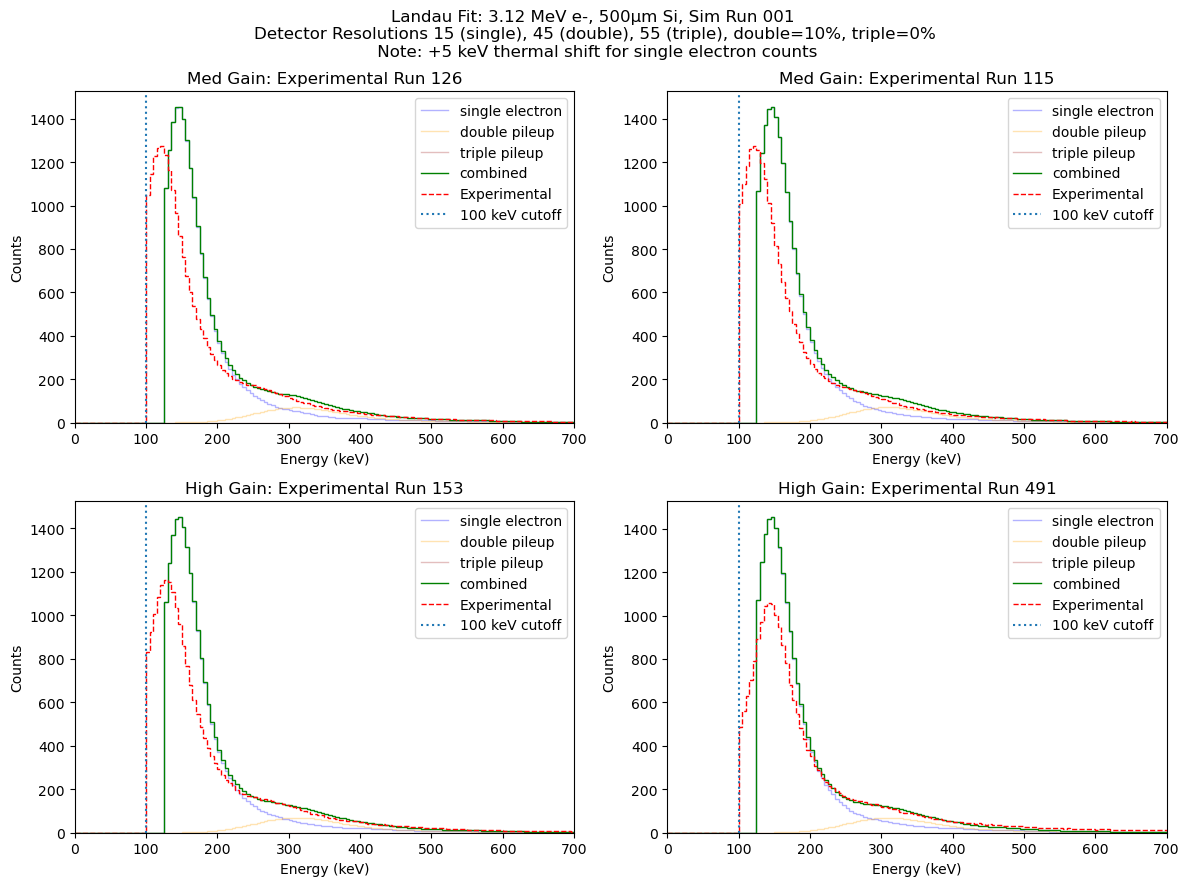

In [232]:
fig,ax = plt.subplots(2,2,figsize=(12,9))

ax = ax.flatten()

runs = [126,115, 153, 491]
exp_runs = [exp_126, exp_115, exp_153, exp_491]

#np.random.seed(42)

for i in range(4):
    double_p = 0.1
    triple_p = 0.0
    sigma_1 = 15 # detector resolution in keV
    sigma_2 = 45
    sigma_3 = 55
    conv_singles, conv_doubles, conv_triples, combined, scaled_exp = make_graph(exp_runs[i], double_p, triple_p, sigma_1, sigma_2, sigma_3)
    ax[i].stairs(conv_singles, bins, label="single electron", color='blue', alpha=0.3)
    ax[i].stairs(conv_doubles, bins, label="double pileup", color='orange', alpha=0.3)
    ax[i].stairs(conv_triples, bins, label="triple pileup", color='brown', alpha=0.3)
    ax[i].stairs(combined, bins, label="combined", color='green')
    ax[i].stairs(scaled_exp, bins, label='Experimental', color='red',linestyle='--')
    ax[i].axvline(100,label='100 keV cutoff', linestyle='dotted')
    ax[i].legend()
    ax[i].set_xlabel('Energy (keV)')
    ax[i].set_ylabel('Counts')
    ax[i].set_xlim(0,700)
    if (i < 2):
        ax[i].set_title(f"Med Gain: Experimental Run {runs[i]}")
    else:
        ax[i].set_title(f"High Gain: Experimental Run {runs[i]}")
plt.suptitle(f"Landau Fit: 3.12 MeV e-, 500μm Si, Sim Run 001 \n"
             f"Detector Resolutions {sigma_1} (single), {sigma_2} (double), {sigma_3} (triple), double={double_p:.0%}, triple={triple_p:.0%}"
             f"\n Note: +5 keV thermal shift for single electron counts")
plt.tight_layout()
plt.savefig("fig/LandauFit_500um_3p12_Med_Gain",dpi=150)
plt.show()

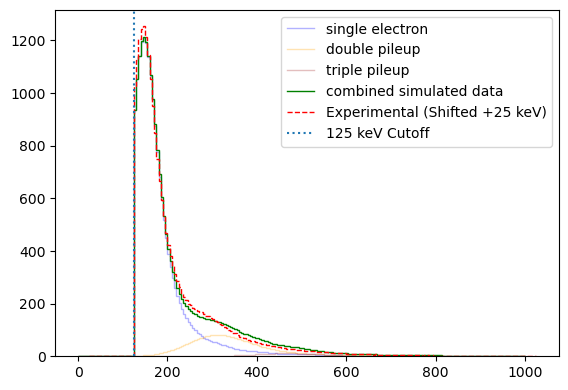

In [233]:
fig,ax=plt.subplots(figsize=(6.5,4.5))
double_p = 0.13
triple_p = 0.02
sigma_1 = 20 # detector resolution in keV
sigma_2 = 55
sigma_3 = 55
conv_singles, conv_doubles, conv_triples, combined, scaled_exp = make_graph(exp_runs[0], double_p, triple_p, sigma_1, sigma_2, sigma_3)
plt.stairs(conv_singles, bins, label="single electron", color='blue', alpha=0.3)
plt.stairs(conv_doubles, bins, label="double pileup", color='orange', alpha=0.3)
plt.stairs(conv_triples, bins, label="triple pileup", color='brown', alpha=0.3)
plt.stairs(combined, bins, label="combined simulated data", color='green')
plt.stairs(scaled_exp, bins + 25, label='Experimental (Shifted +25 keV)', color='red',linestyle='--');
plt.axvline(125,label="125 keV Cutoff", linestyle='dotted')
plt.legend()

## Auto Scipy Fit

In [285]:
from scipy.optimize import differential_evolution
import numpy as np

bin_centers = 0.5 * (bins[:-1] + bins[1:])
CUTOFF = 125.0

def objective(params, exp_run):
    double_p, triple_p, sigma_1, sigma_2, sigma_3 = params
    if double_p + triple_p > 1.0:
        return 1e12
    *_, combined, scaled_exp = make_graph(
        exp_run, double_p, triple_p, sigma_1, sigma_2, sigma_3
    )
    mask = bin_centers >= CUTOFF
    resid = combined[mask] - scaled_exp[mask]
    weights = np.where(scaled_exp[mask] > 0, scaled_exp[mask], 1.0)
    return np.sum(resid**2 / weights)

bounds = [
    (0.0, 0.5),    # double_p
    (0.0, 0.3),    # triple_p
    (1.0, 60.0),   # sigma_1
    (1.0, 100.0),  # sigma_2
    (1.0, 100.0),  # sigma_3
]

res = differential_evolution(
    objective, bounds, args=(exp_runs[0],),
    seed=42, tol=1e-8, maxiter=1000, polish=True,
)

double_p, triple_p, sigma_1, sigma_2, sigma_3 = res.x
print(f"double_p = {double_p:.4f}")
print(f"triple_p = {triple_p:.4f}")
print(f"sigma_1  = {sigma_1:.2f} keV")
print(f"sigma_2  = {sigma_2:.2f} keV")
print(f"sigma_3  = {sigma_3:.2f} keV")
print(f"chi2     = {res.fun:.2f}")
print(f"success  = {res.success}")

double_p = 0.1648
triple_p = 0.0129
sigma_1  = 11.48 keV
sigma_2  = 47.17 keV
sigma_3  = 12.17 keV
chi2     = 3547.13
success  = False


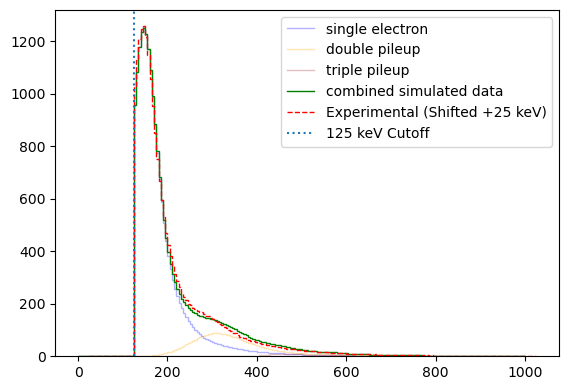

In [297]:
fig,ax=plt.subplots(figsize=(6.5,4.5))
double_p = 0.13
triple_p = 0.0129
sigma_1 = 19 # detector resolution in keV
sigma_2 = 47.17
sigma_3 = 12.17
conv_singles, conv_doubles, conv_triples, combined, scaled_exp = make_graph(exp_runs[0], double_p, triple_p, sigma_1, sigma_2, sigma_3)
plt.stairs(conv_singles, bins, label="single electron", color='blue', alpha=0.3)
plt.stairs(conv_doubles, bins, label="double pileup", color='orange', alpha=0.3)
plt.stairs(conv_triples, bins, label="triple pileup", color='brown', alpha=0.3)
plt.stairs(combined, bins, label="combined simulated data", color='green')
plt.stairs(scaled_exp, bins + 25, label='Experimental (Shifted +25 keV)', color='red',linestyle='--');
plt.axvline(125,label="125 keV Cutoff", linestyle='dotted')
plt.legend()

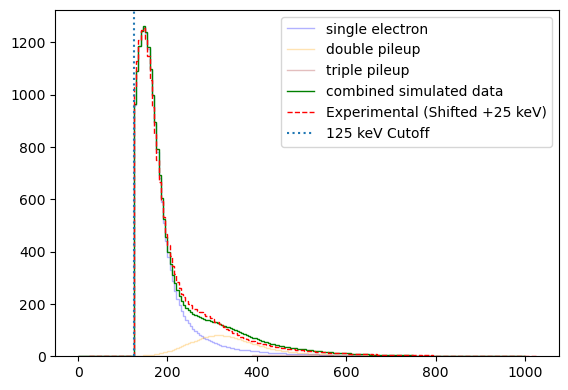

In [284]:
fig,ax=plt.subplots(figsize=(6.5,4.5))
double_p = 0.13
triple_p = 0.0103
sigma_1 = 19 # detector resolution in keV
sigma_2 = 55
sigma_3 = 44.58
conv_singles, conv_doubles, conv_triples, combined, scaled_exp = make_graph(exp_runs[0], double_p, triple_p, sigma_1, sigma_2, sigma_3)
plt.stairs(conv_singles, bins, label="single electron", color='blue', alpha=0.3)
plt.stairs(conv_doubles, bins, label="double pileup", color='orange', alpha=0.3)
plt.stairs(conv_triples, bins, label="triple pileup", color='brown', alpha=0.3)
plt.stairs(combined, bins, label="combined simulated data", color='green')
plt.stairs(scaled_exp, bins + 25, label='Experimental (Shifted +25 keV)', color='red',linestyle='--');
plt.axvline(125,label="125 keV Cutoff", linestyle='dotted')
plt.legend()

In [240]:
base = objective((0.13, 0.02, 20, 55, 55), exp_runs[0])
pert = objective((0.15, 0.02, 20, 55, 55), exp_runs[0])  # nudge double_p
tiny = objective((0.13 + 1e-8, 0.02, 20, 55, 55), exp_runs[0])
print(base, pert, tiny)

4016.144696306274 3975.1569527687975 3967.8500146177753


In [34]:
sim_file.keys()

['Hits;1',
 'Tracks;1',
 'Events;1',
 'Pixels;1',
 'TotalEdep;1',
 'PrimaryEdep;1',
 'EdepMap;1',
 'EntryMap;1']

In [35]:
nums, bins = sim_file["TotalEdep"].to_numpy()

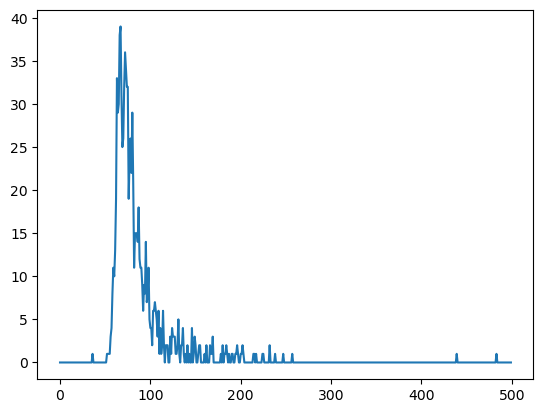

In [36]:
plt.plot(nums)